In [3]:
# Imports
from pathlib import Path
import json
import random
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [4]:
# Automatically locate the project root by searching for README.md.
# This prevents creating models/outputs folders inside the notebooks directory.

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "README.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:", PROJECT_ROOT)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "textcnn"
MODEL_DIR = PROJECT_ROOT / "models" / "textcnn"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Processed data dir:", PROCESSED_DIR)
print("Model dir:", MODEL_DIR)
print("Output dir:", OUTPUT_DIR)

Project root: /Users/eser.arslan/PycharmProjects/SecuritasCaseStudy
Processed data dir: /Users/eser.arslan/PycharmProjects/SecuritasCaseStudy/data/processed
Model dir: /Users/eser.arslan/PycharmProjects/SecuritasCaseStudy/models/textcnn
Output dir: /Users/eser.arslan/PycharmProjects/SecuritasCaseStudy/outputs/textcnn


In [5]:
# Reproducibility
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# TextCNN configuration
TEXT_COL = "text_review_categories_tips"
TARGET_COL = "target_sentiment"

MAX_VOCAB_SIZE = 50_000
MAX_SEQUENCE_LENGTH = 256
EMBEDDING_DIM = 128
BATCH_SIZE = 128
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3
TRAIN_SAMPLE_SIZE = 100_000
VAL_SIZE = 0.10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DEVICE

device(type='cpu')

In [6]:
# Load prepared train/test data from the common data preparation pipeline.
# Pickle is preferred. CSV fallback is included for compatibility.

train_pickle_path = PROCESSED_DIR / "train_model_df.pkl"
test_pickle_path = PROCESSED_DIR / "test_model_df.pkl"

train_csv_path = PROCESSED_DIR / "train_model_df.csv"
test_csv_path = PROCESSED_DIR / "test_model_df.csv"

try:
    train_df = pd.read_pickle(train_pickle_path)
    test_df = pd.read_pickle(test_pickle_path)
    print("Loaded data from pickle files.")
except Exception as exc:
    print("Pickle loading failed. Falling back to CSV.")
    print(exc)

    train_df = pd.read_csv(train_csv_path)
    test_df = pd.read_csv(test_csv_path)

train_df.shape, test_df.shape

Loaded data from pickle files.


((800000, 20), (200000, 20))

In [7]:
# Validate that all required columns exist before training.

required_columns = [
    TEXT_COL,
    TARGET_COL,
]

missing_columns = [
    col for col in required_columns
    if col not in train_df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

train_df[[TEXT_COL, TARGET_COL]].head()

,text_review_categories_tips,target_sentiment
0,Review: Extremely unhelpful customer service. ...,negative
1,"Review: I'm buying a home from 3,000 miles awa...",positive
2,Review: Went to get lunch for myself and my ki...,negative
3,Review: I love Whataburger but on Friday eveni...,negative
4,Review: Amazingly thorough and in addition to ...,positive


In [8]:
# Convert sentiment labels into numeric class IDs.

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2,
}

id2label = {
    v: k for k, v in label2id.items()
}

train_df = train_df.copy()
test_df = test_df.copy()

train_df["label"] = train_df[TARGET_COL].map(label2id)
test_df["label"] = test_df[TARGET_COL].map(label2id)

# Drop rows with unexpected or missing target labels.
train_df = train_df.dropna(subset=["label"]).copy()
test_df = test_df.dropna(subset=["label"]).copy()

train_df["label"] = train_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

train_df[TARGET_COL].value_counts(normalize=True)

target_sentiment
positive    0.668181
negative    0.265271
neutral     0.066547
Name: proportion, dtype: float64

In [9]:
# Sample only from the training set.
# The test set remains untouched and is used only for final evaluation.

if len(train_df) > TRAIN_SAMPLE_SIZE:
    train_sample = (
        train_df
        .groupby(TARGET_COL, group_keys=False)
        .apply(
            lambda x: x.sample(
                n=max(1, int(TRAIN_SAMPLE_SIZE * len(x) / len(train_df))),
                random_state=RANDOM_STATE,
            )
        )
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
else:
    train_sample = train_df.copy()

train_sample.shape, train_sample[TARGET_COL].value_counts(normalize=True)

/var/folders/rm/d17_2hsn66xcjyy0kld__rfc0000gp/T/ipykernel_7015/2750613797.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


((99999, 21),
 target_sentiment
 positive    0.668187
 negative    0.265273
 neutral     0.066541
 Name: proportion, dtype: float64)

In [10]:
# Validation split is created only from the training sample.
# This avoids test leakage during model selection.

textcnn_train_df, textcnn_val_df = train_test_split(
    train_sample,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=train_sample["label"],
)

textcnn_train_df.shape, textcnn_val_df.shape

((89999, 21), (10000, 21))

In [11]:
# Tokenizer and vocabulary
def tokenize(text: str) -> list[str]:
    """
    Simple word-level tokenizer.

    This keeps the TextCNN baseline lightweight and transparent.
    """
    text = str(text).lower()
    return re.findall(r"\b\w+\b", text)


# Build vocabulary from training data only.
# This prevents vocabulary leakage from validation or test data.

counter = Counter()

for text in textcnn_train_df[TEXT_COL].fillna("").astype(str):
    counter.update(tokenize(text))

vocab = {
    "<PAD>": 0,
    "<UNK>": 1,
}

for word, _ in counter.most_common(MAX_VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

len(vocab)

50000

In [12]:
# Text encoding
def encode_text(
    text: str,
    vocab: dict[str, int],
    max_length: int,
) -> list[int]:
    """
    Convert raw text into a fixed-length sequence of token IDs.
    """
    tokens = tokenize(text)

    token_ids = [
        vocab.get(token, vocab["<UNK>"])
        for token in tokens
    ]

    if len(token_ids) >= max_length:
        return token_ids[:max_length]

    padding_length = max_length - len(token_ids)

    return token_ids + [vocab["<PAD>"]] * padding_length

In [13]:
# Dataset Class
class ReviewTextDataset(Dataset):
    """
    PyTorch dataset for review sentiment classification.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        text_col: str,
        label_col: str,
        vocab: dict[str, int],
        max_length: int,
    ):
        self.texts = df[text_col].fillna("").astype(str).tolist()
        self.labels = df[label_col].astype(int).tolist()
        self.vocab = vocab
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        input_ids = encode_text(
            self.texts[idx],
            self.vocab,
            self.max_length,
        )

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [14]:
# Data Loaders
train_dataset = ReviewTextDataset(
    textcnn_train_df,
    TEXT_COL,
    "label",
    vocab,
    MAX_SEQUENCE_LENGTH,
)

val_dataset = ReviewTextDataset(
    textcnn_val_df,
    TEXT_COL,
    "label",
    vocab,
    MAX_SEQUENCE_LENGTH,
)

test_dataset = ReviewTextDataset(
    test_df,
    TEXT_COL,
    "label",
    vocab,
    MAX_SEQUENCE_LENGTH,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

len(train_loader), len(val_loader), len(test_loader)

(704, 79, 1563)

In [15]:
# TextCNN Model
class TextCNN(nn.Module):
    """
    TextCNN for sentence-level sentiment classification.

    The model captures local n-gram patterns such as:
    - "very good"
    - "not worth"
    - "cold food"
    - "friendly staff"
    """

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        num_classes: int,
        num_filters: int = 128,
        kernel_sizes: tuple[int, ...] = (3, 4, 5),
        dropout: float = 0.5,
        padding_idx: int = 0,
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx,
        )

        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    in_channels=embedding_dim,
                    out_channels=num_filters,
                    kernel_size=kernel_size,
                )
                for kernel_size in kernel_sizes
            ]
        )

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(
            num_filters * len(kernel_sizes),
            num_classes,
        )

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        # input_ids shape: [batch_size, sequence_length]
        x = self.embedding(input_ids)

        # Conv1d expects: [batch_size, embedding_dim, sequence_length]
        x = x.permute(0, 2, 1)

        pooled_outputs = []

        for conv in self.convs:
            conv_output = torch.relu(conv(x))

            # Global max pooling over sequence length.
            pooled = torch.max(conv_output, dim=2).values
            pooled_outputs.append(pooled)

        x = torch.cat(pooled_outputs, dim=1)
        x = self.dropout(x)

        return self.classifier(x)

In [16]:
# Initialize Model
model = TextCNN(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    num_classes=len(label2id),
    num_filters=128,
    kernel_sizes=(3, 4, 5),
    dropout=0.5,
    padding_idx=vocab["<PAD>"],
).to(DEVICE)

model

TextCNN(
  (embedding): Embedding(50000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=384, out_features=3, bias=True)
)

In [17]:
# Loss and Optimizer
# Class weights help with class imbalance, especially the minority neutral class.

class_counts = (
    textcnn_train_df["label"]
    .value_counts()
    .sort_index()
    .values
)

class_weights = class_counts.sum() / (len(class_counts) * class_counts)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

class_weights

array([1.25658317, 5.00912785, 0.49886369])

In [18]:
# Training/evaluation helper
def run_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion,
    optimizer=None,
) -> dict[str, float]:
    """
    Run one training or evaluation epoch.

    If optimizer is provided, the model is trained.
    Otherwise, the model is evaluated.
    """
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    for batch in data_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        with torch.set_grad_enabled(is_training):
            logits = model(input_ids)
            loss = criterion(logits, labels)

            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * input_ids.size(0)

        predictions = torch.argmax(logits, dim=1)

        all_predictions.extend(predictions.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    average_loss = total_loss / len(data_loader.dataset)

    return {
        "loss": average_loss,
        "accuracy": accuracy_score(all_labels, all_predictions),
        "macro_f1": f1_score(all_labels, all_predictions, average="macro"),
        "weighted_f1": f1_score(all_labels, all_predictions, average="weighted"),
    }

In [ ]:
# Time : 11:30

In [19]:
# Training Loop
history = []

best_val_macro_f1 = -1.0
best_model_path = MODEL_DIR / "textcnn_model.pt"

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = run_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
    )

    val_metrics = run_epoch(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        optimizer=None,
    )

    epoch_result = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
    }

    history.append(epoch_result)

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"Train loss: {train_metrics['loss']:.4f} | "
        f"Train macro F1: {train_metrics['macro_f1']:.4f} | "
        f"Val loss: {val_metrics['loss']:.4f} | "
        f"Val macro F1: {val_metrics['macro_f1']:.4f}"
    )

    # Save the best model based on validation macro F1.
    if val_metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]

        torch.save(
            model.state_dict(),
            best_model_path,
        )

        print(f"Saved new best model: {best_model_path}")

Epoch 1/5 | Train loss: 0.9061 | Train macro F1: 0.5225 | Val loss: 0.7009 | Val macro F1: 0.5881
Saved new best model: /Users/eser.arslan/PycharmProjects/SecuritasCaseStudy/models/textcnn/textcnn_model.pt
Epoch 2/5 | Train loss: 0.7209 | Train macro F1: 0.6169 | Val loss: 0.5951 | Val macro F1: 0.6586
Saved new best model: /Users/eser.arslan/PycharmProjects/SecuritasCaseStudy/models/textcnn/textcnn_model.pt
Epoch 3/5 | Train loss: 0.6295 | Train macro F1: 0.6615 | Val loss: 0.5680 | Val macro F1: 0.7182
Saved new best model: /Users/eser.arslan/PycharmProjects/SecuritasCaseStudy/models/textcnn/textcnn_model.pt
Epoch 4/5 | Train loss: 0.5627 | Train macro F1: 0.6905 | Val loss: 0.5686 | Val macro F1: 0.6582
Epoch 5/5 | Train loss: 0.4880 | Train macro F1: 0.7256 | Val loss: 0.5567 | Val macro F1: 0.6934


In [ ]:
# time: 12:35

In [20]:
# Training history
history_df = pd.DataFrame(history)

history_df

,epoch,train_loss,train_accuracy,train_macro_f1,train_weighted_f1,val_loss,val_accuracy,val_macro_f1,val_weighted_f1
0,1,0.906121,0.629774,0.522508,0.677313,0.700885,0.6758,0.588108,0.744338
1,2,0.720855,0.735186,0.616876,0.772384,0.595138,0.7657,0.658579,0.805234
2,3,0.629538,0.780331,0.661546,0.811016,0.567967,0.8474,0.718182,0.860654
3,4,0.562654,0.807531,0.690537,0.833958,0.568648,0.7654,0.658244,0.812396
4,5,0.487965,0.835243,0.725573,0.856473,0.556708,0.8114,0.693401,0.837850


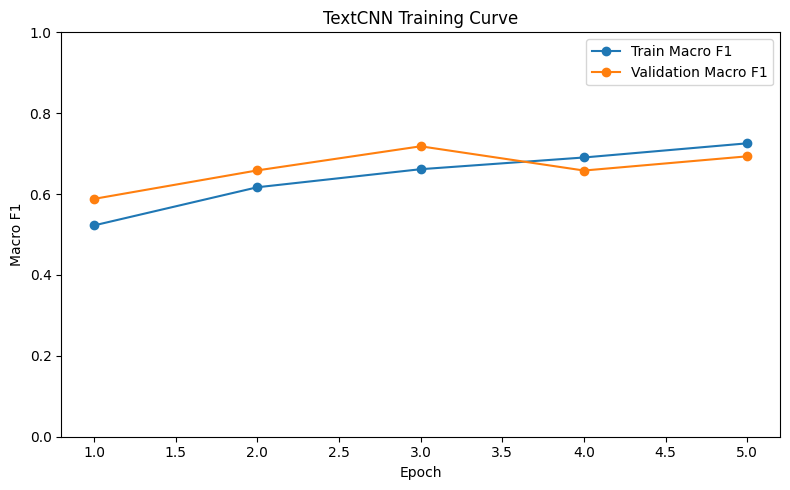

In [21]:
# Traning Curve
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_macro_f1"],
    marker="o",
    label="Train Macro F1",
)

plt.plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    marker="o",
    label="Validation Macro F1",
)

plt.title("TextCNN Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Load best model
best_model = TextCNN(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    num_classes=len(label2id),
    num_filters=128,
    kernel_sizes=(3, 4, 5),
    dropout=0.5,
    padding_idx=vocab["<PAD>"],
).to(DEVICE)

best_model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=DEVICE,
    )
)

best_model.eval()

TextCNN(
  (embedding): Embedding(50000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=384, out_features=3, bias=True)
)

In [23]:
# Test prediction helper
def predict_loader(
    model: nn.Module,
    data_loader: DataLoader,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate predictions and probabilities for a DataLoader.
    """
    model.eval()

    all_probabilities = []
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            logits = model(input_ids)
            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            all_probabilities.append(probabilities.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (
        np.array(all_labels),
        np.array(all_predictions),
        np.vstack(all_probabilities),
    )

In [24]:
# Final test evaluation
test_true_ids, test_pred_ids, test_probabilities = predict_loader(
    best_model,
    test_loader,
)

textcnn_accuracy = accuracy_score(test_true_ids, test_pred_ids)
textcnn_macro_f1 = f1_score(test_true_ids, test_pred_ids, average="macro")
textcnn_weighted_f1 = f1_score(test_true_ids, test_pred_ids, average="weighted")

textcnn_accuracy, textcnn_macro_f1, textcnn_weighted_f1

(0.83652, 0.7144429155615145, 0.8509367530814712)

In [25]:
# Classification report
target_names = ["negative", "neutral", "positive"]

classification_report_dict = classification_report(
    test_true_ids,
    test_pred_ids,
    target_names=target_names,
    output_dict=True,
)

classification_report_df = pd.DataFrame(classification_report_dict).T

classification_report_df

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


,precision,recall,f1-score,support
negative,0.848758,0.802415,0.824936,56153.00000
neutral,0.314495,0.576454,0.406964,14355.00000
positive,0.945025,0.880139,0.911429,129492.00000
accuracy,0.836520,0.836520,0.836520,0.83652
macro avg,0.702759,0.753003,0.714443,200000.00000
weighted avg,0.872740,0.836520,0.850937,200000.00000


In [26]:
# Confusion matrix
cm = confusion_matrix(
    test_true_ids,
    test_pred_ids,
)

cm_df = pd.DataFrame(
    cm,
    index=[f"actual_{label}" for label in target_names],
    columns=[f"pred_{label}" for label in target_names],
)

cm_norm_df = cm_df.div(
    cm_df.sum(axis=1),
    axis=0,
).round(4)

cm_df

,pred_negative,pred_neutral,pred_positive
actual_negative,45058,7400,3695
actual_neutral,3145,8275,2935
actual_positive,4884,10637,113971


In [27]:
# Save predictions
textcnn_test_output = test_df.copy()

textcnn_test_output["textcnn_predicted_label_id"] = test_pred_ids

textcnn_test_output["textcnn_predicted_sentiment"] = [
    id2label[int(label_id)]
    for label_id in test_pred_ids
]

for label_name, label_id in label2id.items():
    textcnn_test_output[f"textcnn_prob_{label_name}"] = test_probabilities[:, label_id]

textcnn_prediction_path = PROCESSED_DIR / "textcnn_test_predictions.pkl"

textcnn_test_output.to_pickle(textcnn_prediction_path)

print("Saved TextCNN predictions to:", textcnn_prediction_path)

textcnn_test_output.head()

OSError: [Errno 28] No space left on device: '/Users/eser.arslan/PycharmProjects/SecuritasCaseStudy/data/processed/textcnn_test_predictions.pkl'

In [ ]:
# Save model artifacts
# Save vocabulary and model metadata for reproducibility.

vocab_path = MODEL_DIR / "vocab.json"
metadata_path = MODEL_DIR / "metadata.json"

with open(vocab_path, "w", encoding="utf-8") as file:
    json.dump(vocab, file)

metadata = {
    "model_name": "TextCNN",
    "text_col": TEXT_COL,
    "target_col": TARGET_COL,
    "max_vocab_size": MAX_VOCAB_SIZE,
    "actual_vocab_size": len(vocab),
    "max_sequence_length": MAX_SEQUENCE_LENGTH,
    "embedding_dim": EMBEDDING_DIM,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "train_sample_size": len(train_sample),
    "train_size_used": len(textcnn_train_df),
    "validation_size": len(textcnn_val_df),
    "test_size": len(test_df),
    "best_val_macro_f1": best_val_macro_f1,
    "label2id": label2id,
    "id2label": id2label,
}

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print("Saved vocabulary to:", vocab_path)
print("Saved metadata to:", metadata_path)

In [ ]:
# Save outputs
history_df.to_csv(
    OUTPUT_DIR / "textcnn_training_history.csv",
    index=False,
)

cm_df.to_csv(
    OUTPUT_DIR / "textcnn_confusion_matrix.csv",
)

cm_norm_df.to_csv(
    OUTPUT_DIR / "textcnn_confusion_matrix_normalized.csv",
)

classification_report_df.to_csv(
    OUTPUT_DIR / "textcnn_classification_report.csv",
)

with open(OUTPUT_DIR / "textcnn_classification_report.json", "w", encoding="utf-8") as file:
    json.dump(classification_report_dict, file, indent=2)

textcnn_metrics = {
    "model": "TextCNN",
    "accuracy": textcnn_accuracy,
    "macro_f1": textcnn_macro_f1,
    "weighted_f1": textcnn_weighted_f1,
    "best_val_macro_f1": best_val_macro_f1,
    "train_sample_size": len(train_sample),
    "train_size_used": len(textcnn_train_df),
    "validation_size": len(textcnn_val_df),
    "test_size": len(test_df),
}

with open(OUTPUT_DIR / "textcnn_model_metrics.json", "w", encoding="utf-8") as file:
    json.dump(textcnn_metrics, file, indent=2)

textcnn_metrics

In [28]:
# Compare with TF-IDF and BERT
comparison_rows = []

# Load TF-IDF metrics.
tfidf_metrics_path = PROJECT_ROOT / "outputs" / "model_metrics.json"

if tfidf_metrics_path.exists():
    with open(tfidf_metrics_path, "r", encoding="utf-8") as file:
        tfidf_metrics = json.load(file)

    comparison_rows.append(
        {
            "model": "TF-IDF + Logistic Regression",
            "accuracy": tfidf_metrics["accuracy"],
            "macro_f1": tfidf_metrics["macro_f1"],
            "weighted_f1": tfidf_metrics["weighted_f1"],
            "training_cost": "Low",
            "inference_cost": "Very Low",
            "interpretability": "High",
        }
    )

# Load BERT metrics.
bert_metrics_path = PROJECT_ROOT / "outputs" / "bert" / "bert_model_metrics.json"

if bert_metrics_path.exists():
    with open(bert_metrics_path, "r", encoding="utf-8") as file:
        bert_metrics = json.load(file)

    comparison_rows.append(
        {
            "model": "DistilBERT",
            "accuracy": bert_metrics["accuracy"],
            "macro_f1": bert_metrics["macro_f1"],
            "weighted_f1": bert_metrics["weighted_f1"],
            "training_cost": "High",
            "inference_cost": "Medium-High",
            "interpretability": "Low-Medium",
        }
    )

# Add TextCNN metrics.
comparison_rows.append(
    {
        "model": "TextCNN",
        "accuracy": textcnn_accuracy,
        "macro_f1": textcnn_macro_f1,
        "weighted_f1": textcnn_weighted_f1,
        "training_cost": "Medium",
        "inference_cost": "Low-Medium",
        "interpretability": "Medium",
    }
)

comparison_df = pd.DataFrame(comparison_rows)

comparison_df

,model,accuracy,macro_f1,weighted_f1,training_cost,inference_cost,interpretability
0,TF-IDF + Logistic Regression,0.875785,0.748692,0.885009,Low,Very Low,High
1,DistilBERT,0.918260,0.779048,0.914610,High,Medium-High,Low-Medium
2,TextCNN,0.836520,0.714443,0.850937,Medium,Low-Medium,Medium


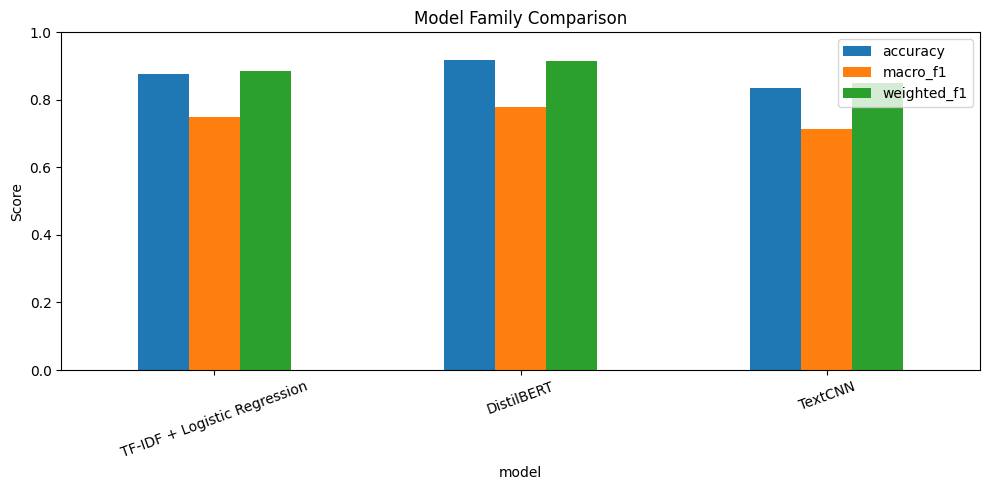

In [29]:
# Plot Comparison
plot_df = comparison_df.set_index("model")[["accuracy", "macro_f1", "weighted_f1"]]

plot_df.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Model Family Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()